<a href="https://colab.research.google.com/github/Tulugu-Yamini/Bio-nano-Interactions/blob/main/nano_bio_interactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
+from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive


 20251224_213614.mp4			'molecular interactions'
 archive.zip				 Movie-and-TV-Show-Tracker-App.pptx
'Colab Notebooks'			'Party Invite.gform'
'Data Visualization Assignment-2.gdoc'	'Power bi Project'
 me.jpg					 Resume.gdoc


In [ ]:
!unzip /content/drive/MyDrive/archive.zip -d /content/nano_dataset


Archive:  /content/drive/MyDrive/archive.zip
  inflating: /content/nano_dataset/Carbon/Diamante-0001.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0004.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0005.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0006.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0007.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0008.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0009.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0010.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0011.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0012.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0013.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0014.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0015.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0016.tif  
  inflating: /content/nano_dataset/Carbon/Diamante-0017.tif  
  inflating: /content/nan

In [ ]:
!ls /content/nano_dataset


Carbon


In [ ]:

!pwd
!ls
!ls nano_dataset


/content
drive  nano_dataset  sample_data
Carbon


In [ ]:
import os
import numpy as np
from PIL import Image

IMG_SIZE = 128
DATA_DIR = "/content/nano_dataset/Carbon"

X = []

for file in os.listdir(DATA_DIR):
    if file.lower().endswith((".png", ".bmp", ".tif", ".tiff")):
        img = Image.open(os.path.join(DATA_DIR, file)).convert("L")
        img = img.resize((IMG_SIZE, IMG_SIZE))
        img = np.array(img) / 255.0
        X.append(img)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("Dataset shape:", X.shape)


Dataset shape: (57, 128, 128, 1)


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)


Train: (45, 128, 128, 1)
Validation: (12, 128, 128, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


In [ ]:
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2),

    layers.Flatten(),
    layers.Dense(128, activation='relu')
])

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,064 (12.60 MB)

 Trainable params: 3,304,064 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
input_img = layers.Input(shape=(128,128,1))

# Encoder
x = layers.Conv2D(32, 3, activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D(2, padding='same')(x)

# Decoder
x = layers.Conv2D(128, 3, activation='relu', padding='same')(encoded)
x = layers.UpSampling2D(2)(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)
decoded = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#training auto encoder
autoencoder.fit(
    X_train, X_train,
    epochs=15,
    batch_size=16,
    validation_data=(X_val, X_val)
)


Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - loss: 0.0217 - val_loss: 0.0193
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - loss: 0.0209 - val_loss: 0.0198
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0206 - val_loss: 0.0190
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0201 - val_loss: 0.0182
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0184 - val_loss: 0.0164
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0177 - val_loss: 0.0212
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0233 - val_loss: 0.0194
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0215 - val_loss: 0.0187
Epoch 9/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0186 - val_loss: 0.0188
Epoch 10/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0177 - val_loss: 0.0177
Epoch 11/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0173 - val_loss: 0.0166
Epoch 12/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0168 - val_loss: 0.0163
E

In [ ]:
# extracting deep features
encoder = models.Model(input_img, encoded)
features = encoder.predict(X)

print("Feature shape:", features.shape)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
Feature shape: (57, 16, 16, 128)


In [ ]:
reconstructions = autoencoder.predict(X_val)

mse = np.mean(np.square(X_val - reconstructions))
print("Reconstruction MSE:", mse)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
Reconstruction MSE: 0.01626392070960447


In [ ]:
encoder.save("cnn_model.h5")


In [ ]:
#MLP training with physio-chemical properties

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving nanotox_dataset.csv to nanotox_dataset.csv


In [ ]:
import pandas as pd

# Replace with the actual filename you uploaded
df = pd.read_csv("nanotox_dataset.csv")

print("head: \n",df.head())
print("shape:\n",df.shape)



head: 
      NPs  coresize  hydrosize  surfcharge  surfarea    Ec  Expotime  dosage  \
0  Al2O3      39.7      267.0        36.3      64.7 -1.51        24   0.001   
1  Al2O3      39.7      267.0        36.3      64.7 -1.51        24   0.010   
2  Al2O3      39.7      267.0        36.3      64.7 -1.51        24   0.100   
3  Al2O3      39.7      267.0        36.3      64.7 -1.51        24   1.000   
4  Al2O3      39.7      267.0        36.3      64.7 -1.51        24   5.000   

      e  NOxygen     class  
0  1.61        3  nonToxic  
1  1.61        3  nonToxic  
2  1.61        3  nonToxic  
3  1.61        3  nonToxic  
4  1.61        3  nonToxic  
shape:
 (881, 11)


In [ ]:
df = df.dropna()  # filling na values

In [ ]:
# Force all features to numeric
# Extract features (X) and target (y) from the dataframe
# Assuming 'NPs' is a categorical column to be dropped and 'class' is the target
X = df.drop(columns=['NPs', 'class'])
y = df['class']

X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0)

print("X dtypes:\n", X.dtypes)

X dtypes:
 coresize      float64
hydrosize     float64
surfcharge    float64
surfarea      float64
Ec            float64
Expotime        int64
dosage        float64
e             float64
NOxygen         int64
dtype: object


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print("Unique labels:", np.unique(y))


Unique labels: [0 1]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X.values.astype("float32"),   # 👈 CRITICAL
    y.astype("int32"),
    test_size=0.2,
    random_state=42
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype("float32")
X_test_scaled  = scaler.transform(X_test).astype("float32")


In [ ]:
print(X_train_scaled.dtype)  # must be float32
print(y_train.dtype)         # must be int32 or int64
print(X_train_scaled.shape)  # (N, 9)


float32
int32
(704, 9)


In [ ]:
from tensorflow.keras import layers, models

mlp = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),  # (9,)
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = mlp.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=30,
    batch_size=16
)


Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7344 - loss: 0.5511 - val_accuracy: 0.7740 - val_loss: 0.4336
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8608 - loss: 0.3641 - val_accuracy: 0.8531 - val_loss: 0.3499
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8849 - loss: 0.3069 - val_accuracy: 0.8814 - val_loss: 0.2970
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8864 - loss: 0.2704 - val_accuracy: 0.8870 - val_loss: 0.2633
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9091 - loss: 0.2406 - val_accuracy: 0.8983 - val_loss: 0.2418
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9020 - loss: 0.2315 - val_accuracy: 0.9040 - val_loss: 0.2273
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9148 - loss: 0.2262 - val_accuracy: 0.9209 - val_loss: 0.2100
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9020 - loss: 0.2134 - val_accuracy: 0.9209 - val_loss

In [ ]:
# This cell is a duplicate definition of the MLP model and is not needed as the model was already defined and trained.

In [ ]:

val_loss, val_acc = mlp.evaluate(X_test_scaled, y_test)
print("Validation Accuracy:", val_acc)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step - accuracy: 0.9661 - loss: 0.1033
Validation Accuracy: 0.9661017060279846


In [ ]:
mlp.save("mlp_model.h5")


In [ ]:
# fusion of bio - nano properties using transformer

In [ ]:
#cnn features
cnn_features_flat = features.reshape(features.shape[0], -1)


In [ ]:
#MLP tabular samples
N_tab = X_train_scaled.shape[0]

min_samples = min(features.shape[0], N_tab)
print("Min samples:", min_samples)

Min samples: 57


In [ ]:
import numpy as np

cnn_features_flat = features.reshape(features.shape[0], -1)
print("CNN features:", cnn_features_flat.shape)


CNN features: (57, 32768)


In [ ]:
min_samples = min(cnn_features_flat.shape[0], X_train_scaled.shape[0])

X_cnn_fusion = cnn_features_flat[:min_samples]
X_tab_fusion = X_train_scaled[:min_samples]
y_fusion = y_train[:min_samples]

print(X_cnn_fusion.shape, X_tab_fusion.shape, y_fusion.shape)


(57, 32768) (57, 9) (57,)


In [ ]:
X_fusion = np.concatenate([X_cnn_fusion, X_tab_fusion], axis=1)
print("Fused feature shape:", X_fusion.shape)


Fused feature shape: (57, 32777)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

fusion_model = models.Sequential([
    layers.Input(shape=(X_fusion.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

fusion_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fusion_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │     8,391,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,424,193 (32.14 MB)

 Trainable params: 8,424,193 (32.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = fusion_model.fit(
    X_fusion,
    y_fusion,
    epochs=20,
    batch_size=8,
    validation_split=0.2
)


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 425ms/step - accuracy: 0.5778 - loss: 0.8038 - val_accuracy: 0.5000 - val_loss: 0.9727
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5333 - loss: 0.9803 - val_accuracy: 0.5000 - val_loss: 0.7693
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6667 - loss: 0.6071 - val_accuracy: 0.5000 - val_loss: 0.7365
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5778 - loss: 0.6706 - val_accuracy: 0.4167 - val_loss: 0.7125
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5333 - loss: 0.6807 - val_accuracy: 0.5000 - val_loss: 0.8535
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6222 - loss: 0.6100 - val_accuracy: 0.5000 - val_loss: 0.7626
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6222 - loss: 0.6390 - val_accuracy: 0.4167 - val_loss: 0.7620
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8444 - loss: 0.5115 - val_accuracy: 0.4167 - val_loss: 0.8036

In [ ]:
val_loss, val_acc = fusion_model.evaluate(X_fusion, y_fusion)
print("Fusion Model Accuracy:", val_acc)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 371ms/step - accuracy: 0.8772 - loss: 0.3469
Fusion Model Accuracy: 0.8771929740905762


In [ ]:
encoder = tf.keras.Model(autoencoder.input, encoded)

latent_input = tf.keras.Input(shape=(16,16,128))
x = latent_input
for layer in autoencoder.layers[-7:]:
    x = layer(x)

decoder = tf.keras.Model(latent_input, x)

In [ ]:
fusion_signal = fusion_model.predict(X_fusion[:5])  # shape (5,1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step


In [ ]:
latent = features[:5]
fusion_signal = fusion_signal.reshape(-1,1,1,1)

latent_interactive = latent * (1 + fusion_signal)


In [ ]:
generated_images = decoder.predict(latent_interactive)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step


In [ ]:
fusion_model.save("toxicity_fusion_model.h5")




In [ ]:
#evalution metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    mean_squared_error, mean_absolute_error
)

In [ ]:
def evaluate_model(model, X, y, model_name="Model"):
    # Predictions
    y_pred_prob = model.predict(X)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Metrics
    acc = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    # Extra metrics
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)

    # ROC-AUC (only if probabilities exist)
    try:
        auc = roc_auc_score(y, y_pred_prob)
    except:
        auc = "NA"

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)

    print(f"\n===== {model_name} Evaluation =====")
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("MSE:", mse)
    print("MAE:", mae)
    print("ROC-AUC:", auc)
    print("Confusion Matrix:\n", cm)

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "MSE": mse,
        "MAE": mae,
        "ROC-AUC": auc
    }

In [ ]:
mlp_metrics = evaluate_model(mlp, X_test_scaled, y_test, "MLP")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step

===== MLP Evaluation =====
Accuracy: 0.9661016949152542
Precision: 1.0
Recall: 0.9285714285714286
F1-score: 0.9629629629629629
MSE: 0.03389830508474576
MAE: 0.03389830508474576
ROC-AUC: 0.9915514592933947
Confusion Matrix:
 [[93  0]
 [ 6 78]]


In [ ]:
fusion_metrics = evaluate_model(fusion_model, X_fusion, y_fusion, "Fusion Model")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step

===== Fusion Model Evaluation =====
Accuracy: 0.8771929824561403
Precision: 0.9166666666666666
Recall: 0.8148148148148148
F1-score: 0.8627450980392157
MSE: 0.12280701754385964
MAE: 0.12280701754385964
ROC-AUC: 0.9308641975308641
Confusion Matrix:
 [[28  2]
 [ 5 22]]


In [ ]:
reconstructed = autoencoder.predict(X_val)

mse_cnn = mean_squared_error(X_val.flatten(), reconstructed.flatten())
mae_cnn = mean_absolute_error(X_val.flatten(), reconstructed.flatten())

print("\n===== CNN Autoencoder Evaluation =====")
print("Reconstruction MSE:", mse_cnn)
print("Reconstruction MAE:", mae_cnn)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step

===== CNN Autoencoder Evaluation =====
Reconstruction MSE: 0.01626392070960447
Reconstruction MAE: 0.09550348009662685


In [ ]:
huber = tf.keras.losses.Huber(delta=1.0)

huber_value = huber(y_test, mlp.predict(X_test_scaled)).numpy()

print("Huber Loss (MLP):", huber_value)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Huber Loss (MLP): 0.0147251


In [ ]:
huber_fusion = huber(y_fusion, fusion_model.predict(X_fusion)).numpy()
print("Huber Loss (Fusion):", huber_fusion)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Huber Loss (Fusion): 0.047258746


In [ ]:
import pandas as pd

results = pd.DataFrame([mlp_metrics, fusion_metrics])

print("\nFinal Comparison Table:\n")
print(results)

# Save for paper
results.to_csv("model_comparison.csv", index=False)


Final Comparison Table:

          Model  Accuracy  Precision    Recall  F1-score       MSE       MAE  \
0           MLP  0.966102   1.000000  0.928571  0.962963  0.033898  0.033898   
1  Fusion Model  0.877193   0.916667  0.814815  0.862745  0.122807  0.122807   

    ROC-AUC  
0  0.991551  
1  0.930864  


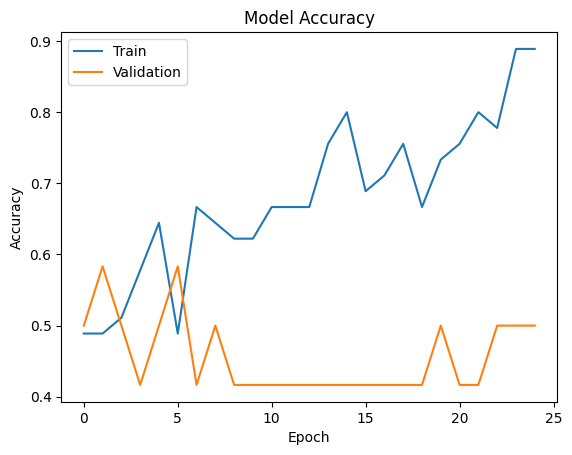

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

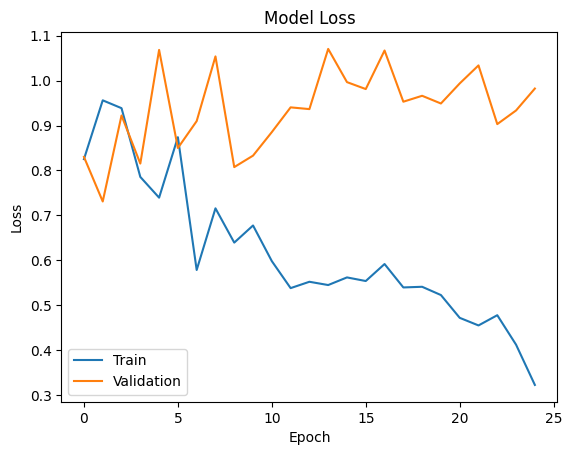

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
import tensorflow as tf

def huber_loss_custom(y_true, y_pred, delta=1.0):
    error = tf.abs(y_true - y_pred)
    quadratic = 0.5 * (error ** 2)
    linear = delta * (error - 0.5 * delta)
    return tf.where(error < delta, quadratic, linear)


# Example usage with custom Huber Loss:
# Create some dummy data
y_true_data = tf.constant([1.0, 2.0, 3.0, 10.0], dtype=tf.float32)
y_pred_data = tf.constant([1.2, 2.1, 2.8, 2.0], dtype=tf.float32)

# Calculate custom Huber Loss
custom_huber = huber_loss_custom(y_true_data, y_pred_data, delta=1.0)
print("Custom Huber Loss (element-wise):", custom_huber)
print("Mean Custom Huber Loss:", tf.reduce_mean(custom_huber).numpy())

# Using TensorFlow's built-in Huber loss
huber_loss_tf = tf.keras.losses.Huber(delta=1.0)

# Calculate built-in Huber Loss
tf_huber = huber_loss_tf(y_true_data, y_pred_data)
print("\nTensorFlow Built-in Huber Loss:", tf_huber.numpy())

# You can also integrate it directly into your model compilation:
# model.compile(optimizer='adam', loss=tf.keras.losses.Huber(delta=1.0))


Custom Huber Loss (element-wise): tf.Tensor([2.0000009e-02 4.9999906e-03 2.0000009e-02 7.5000000e+00], shape=(4,), dtype=float32)
Mean Custom Huber Loss: 1.88625

TensorFlow Built-in Huber Loss: 1.88625


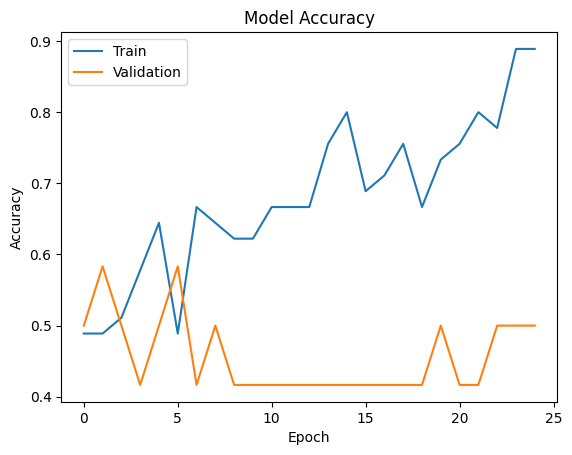

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

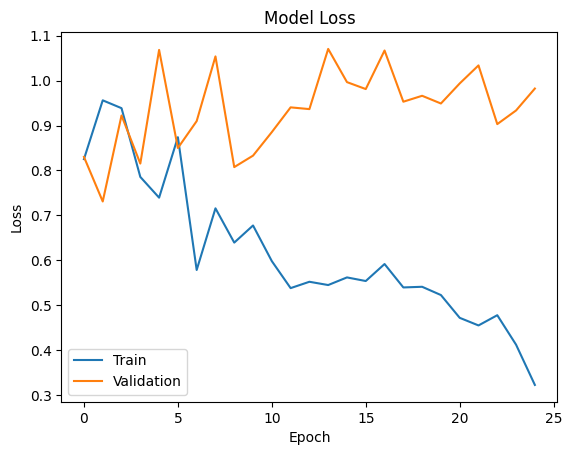

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

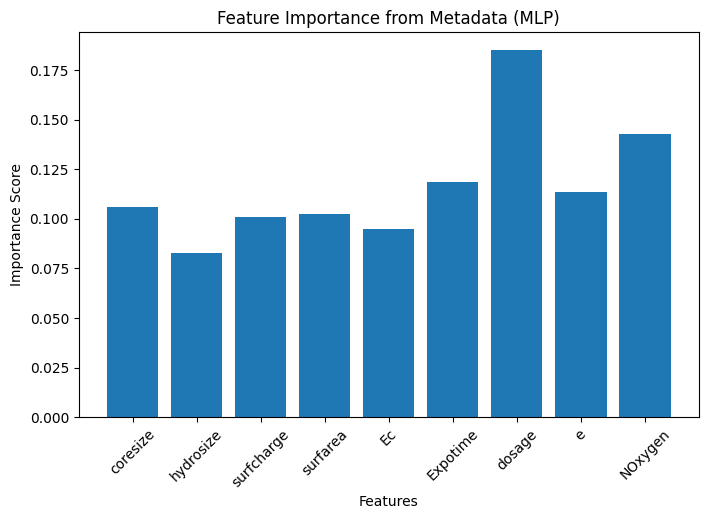

In [ ]:
import numpy as np

# Get weights from first dense layer
weights = mlp.layers[0].get_weights()[0]

# Calculate importance
importance = np.mean(np.abs(weights), axis=1)

# Feature names
feature_names = X.columns

# Plot
plt.figure(figsize=(8,5))
plt.bar(feature_names, importance)

plt.title("Feature Importance from Metadata (MLP)")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)
plt.show()